# MPoint2d (Multiple Points 2D) Tutorial

This notebook demonstrates the usage of the `MPoint2d` class from the `upxo.geoEntities` package, which provides functionality for working with collections of 2D points.

## Overview

The `MPoint2d` class is a powerful tool for handling multiple 2D points with various operations including:

- **Point Creation**: Generate point collections from coordinates, clustering, or geometric intersections
- **Point Manipulation**: Add, append, and transform point collections
- **Geometric Operations**: Create points from line intersections and spatial distributions
- **Visualization**: Built-in plotting capabilities for analyzing point distributions

## Notebook Contents

1. **Basic Operations**: Creating point collections from random coordinates and performing arithmetic operations
2. **Clustering**: Generating point clusters around centroids with different distribution patterns
3. **Line-Based Generation**: Creating point distributions along lines with various spacing configurations
4. **Intersection Analysis**: Computing intersection points between two sets of lines

This tutorial will walk through practical examples of each feature, demonstrating how to leverage `MPoint2d` for geometric analysis and spatial data processing.

In [1]:
import numpy as np
from upxo.geoEntities.mulpoint2d import MPoint2d as mp2d
import matplotlib.pyplot as plt

c:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
c:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:

mulpoint2d = mp2d.from_coords(np.random.random((10,2)))
mulpoint2d.coords

array([[0.62932136, 0.42708686],
       [0.44857022, 0.12049367],
       [0.26233918, 0.08373227],
       [0.06894693, 0.417919  ],
       [0.87718855, 0.79980694],
       [0.83118283, 0.60748254],
       [0.63839381, 0.3297429 ],
       [0.099869  , 0.49734315],
       [0.13006509, 0.22711876],
       [0.25368106, 0.16879955]])

In [3]:
mulpoint2d.add(toadd=10, operation='add')
mulpoint2d.coords

array([[10.62932136, 10.42708686],
       [10.44857022, 10.12049367],
       [10.26233918, 10.08373227],
       [10.06894693, 10.417919  ],
       [10.87718855, 10.79980694],
       [10.83118283, 10.60748254],
       [10.63839381, 10.3297429 ],
       [10.099869  , 10.49734315],
       [10.13006509, 10.22711876],
       [10.25368106, 10.16879955]])

In [4]:
mulpoint2d.add(toadd=[-10, 20], operation='add')
mulpoint2d.coords

array([[ 0.62932136, 30.42708686],
       [ 0.44857022, 30.12049367],
       [ 0.26233918, 30.08373227],
       [ 0.06894693, 30.417919  ],
       [ 0.87718855, 30.79980694],
       [ 0.83118283, 30.60748254],
       [ 0.63839381, 30.3297429 ],
       [ 0.099869  , 30.49734315],
       [ 0.13006509, 30.22711876],
       [ 0.25368106, 30.16879955]])

In [5]:
mulpoint2d.add(toadd=np.random.random((mulpoint2d.n, 2)), operation='add')
mulpoint2d.coords

array([[ 0.62932136, 30.42708686],
       [ 0.44857022, 30.12049367],
       [ 0.26233918, 30.08373227],
       [ 0.06894693, 30.417919  ],
       [ 0.87718855, 30.79980694],
       [ 0.83118283, 30.60748254],
       [ 0.63839381, 30.3297429 ],
       [ 0.099869  , 30.49734315],
       [ 0.13006509, 30.22711876],
       [ 0.25368106, 30.16879955]])

In [6]:
mulpoint2d.add(toadd=np.random.random((10,2)), operation='append')
mulpoint2d.coords

array([[ 0.62932136, 30.42708686],
       [ 0.44857022, 30.12049367],
       [ 0.26233918, 30.08373227],
       [ 0.06894693, 30.417919  ],
       [ 0.87718855, 30.79980694],
       [ 0.83118283, 30.60748254],
       [ 0.63839381, 30.3297429 ],
       [ 0.099869  , 30.49734315],
       [ 0.13006509, 30.22711876],
       [ 0.25368106, 30.16879955]])

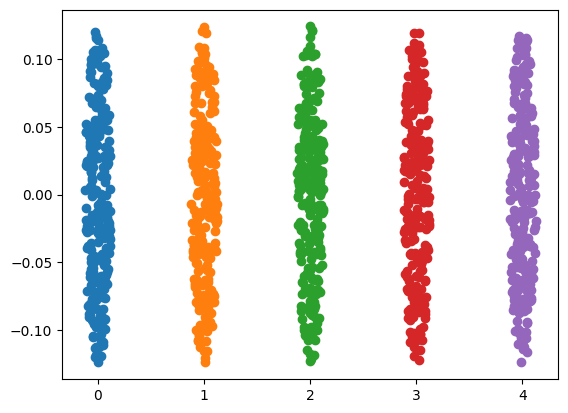

In [7]:
from upxo.geoEntities.mulpoint2d import MPoint2d
cenx, ceny = [0, 1, 2, 3, 4], [0, 0, 0, 0, 0]
for cx, cy in zip(cenx, ceny):
    MP2D = MPoint2d.from_clustering_around_centroid((cx, cy),
                                                    n=250, r=0.25,
                                                    distribution='urand',
                                                    dmin=0.1)
    plt.scatter(MP2D.coords[:,0],MP2D.coords[:,1])

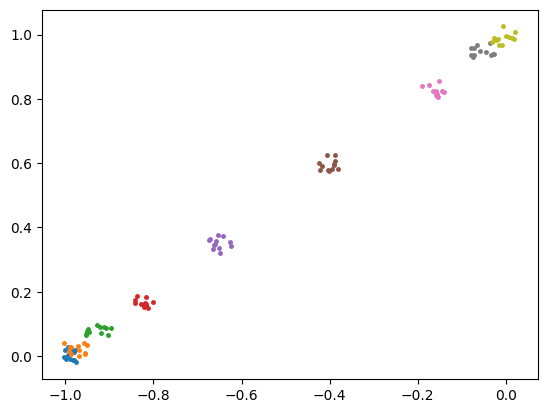

In [8]:
from upxo.geoEntities.mulpoint2d import MPoint2d
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(-1, 0, 0, 1)
refpoints = line.distribute_points(n=[5, 3],
                                    spacing='constant', factor=0.6,
                                    sub_spacing=['cubic','cubic'],
                                    subfactors=[0, 1],
                                    trim_ij=True,
                                    _coord_rounding_=(True, 8),
                                    _plot_=False)
for refpnt in refpoints:
    MP2D = MPoint2d.from_clustering_around_centroid((refpnt[0],
                                                        refpnt[1]),
                                                    n=12, r=0.1,
                                                    distribution='urand',
                                                    dmin=0.1)
    plt.plot(MP2D.coords[:,0],MP2D.coords[:,1], '.', ms=5)

([uxpo-p2d (-0.30033024557817334,-0.34391529651484654),
  uxpo-p2d (-3.168065845360193,-2.8954818618539213),
  uxpo-p2d (-1.9127084348942058,-1.7785281244385445),
  uxpo-p2d (0.8004153819577203,0.6354726709035068),
  uxpo-p2d (-0.6608637052117288,-0.6646997932993234),
  uxpo-p2d (0.006194962767774563,-0.004691246863222079),
  uxpo-p2d (-3.4885801199424677,-3.2400240812514944),
  uxpo-p2d (-1.926628084920557,-1.7940269612517243),
  uxpo-p2d (1.6149386349030985,1.4846238310437),
  uxpo-p2d (-0.3927201060108736,-0.3739919857110342),
  uxpo-p2d (0.7095302437779701,0.7736729326266043),
  uxpo-p2d (-3.206410381401139,-2.936700966889215),
  uxpo-p2d (-1.5052457315577334,-1.324838704480872),
  uxpo-p2d (3.161421969122568,3.0968529634120054),
  uxpo-p2d (0.36308773431736063,0.4454168716127543),
  uxpo-p2d (1.1241067868732264,1.2324747864715988),
  uxpo-p2d (-1.9192440148719285,-1.5530397953676836),
  uxpo-p2d (-0.7446777570918134,-0.47798415718533216),
  uxpo-p2d (3.1640414938388313,3.099583852

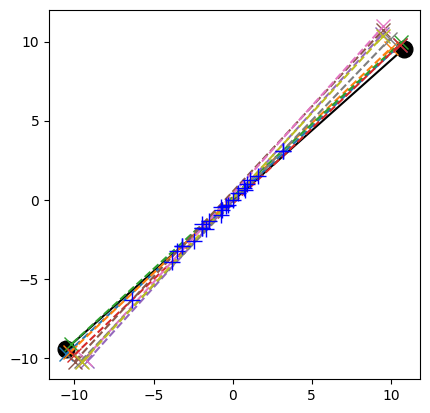

In [9]:
from upxo.geoEntities.sline2d import Sline2d
from upxo.geoEntities.point2d import Point2d
from upxo.geoEntities.mulpoint2d import MPoint2d

na, nb = 5, 5
R = np.random.rand
La = [Sline2d.by_coord([-10-R(),-10+R()], [10+R(),10-R()])
        for _ in range(na)]
Lb = [Sline2d.by_coord([-10+R(),-10-R()], [10-R(),10+R()])
        for _ in range(nb)]
MPoint2d.from_intersection_linesA_linesB(La, Lb,
                                            return_ordered_points=True,
                                            plot=True)
MP2D = MPoint2d.from_intersection_linesA_linesB(La, Lb,
                                                return_ordered_points=False,
                                                plot=False)
MP2D.points, MP2D.coords